# SLM-Based Framework for Imputation and Prediction (Regression)
### Model: **TabM** | Dataset: `AP001.csv` | Target: `PM2.5 (ug/m3)`

**Station:** AP001 — Hourly air quality & meteorological sensor readings (2016–2023)  
**Rows:** 59,150 hourly observations | **Features:** 21 sensor/weather columns  
**Target:** `PM2.5 (ug/m3)` (continuous regression)

| Step | Description | Output Folder |
|------|-------------|---------------|
| 0 | Install dependencies | — |
| 1 | Imports & configuration | — |
| 2 | Setup project folders | `data/raw/`, `data/processed/`, `models/`, `results/`, `logs/` |
| 3 | Load raw dataset (auto-locates `AP001.csv`) | `data/raw/` |
| 4 | EDA — exploratory data analysis | `results/` |
| 5 | Feature engineering & preprocessing | — |
| 6 | Traditional imputation (Median) | `data/processed/` |
| 7 | **TabM architecture** | — |
| 8 | Training & evaluation utilities | `logs/` |
| 9 | Train TabM — Traditional (Median) imputation | `models/`, `logs/` |
| 10 | SLM-based imputation (RandomForest) | `data/processed/` |
| 11 | Train TabM — SLM-based imputation | `models/`, `logs/` |
| 12 | Training curve plots | `results/` |
| 13 | Predicted vs Actual plots | `results/` |
| 14 | PM2.5 distribution + residual plots | `results/` |
| 15 | Final results & comparison | `results/` |
| 16 | Feature importance analysis | `results/` |
| 17 | Folder summary | — |

## Step 0: Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn --quiet
!{sys.executable} -m pip install torch --index-url https://download.pytorch.org/whl/cpu --quiet
!{sys.executable} -m pip install ipykernel --quiet
print('All packages ready! Restart kernel if running for the first time.')


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All packages ready! Restart kernel if running for the first time.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Imports & Configuration

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Setup complete.')

Device : cpu
Setup complete.


## Step 2: Setup Project Folders
All output artefacts are written to structured sub-folders inside the project root.

```
AP001_TabM_Project/
├── data/
│   ├── raw/          ← AP001.csv lives here
│   └── processed/    ← median & SLM imputed CSVs
├── models/           ← trained .pt weight files
├── results/          ← all plots + comparison CSV
└── logs/             ← training log .txt files
```

In [3]:
# ── Auto-detect project root ──────────────────────────────────────────────────
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = (
    os.path.dirname(NOTEBOOK_DIR)
    if os.path.basename(NOTEBOOK_DIR) == 'notebooks'
    else NOTEBOOK_DIR
)

# ── Create all sub-folders ────────────────────────────────────────────────────
for folder in ['data/raw', 'data/processed', 'models', 'results', 'logs']:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

DATA_RAW       = os.path.join(PROJECT_ROOT, 'data', 'raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR     = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR    = os.path.join(PROJECT_ROOT, 'results')
LOGS_DIR       = os.path.join(PROJECT_ROOT, 'logs')

print(f'Project Root   : {PROJECT_ROOT}')
print(f'data/raw/      : {DATA_RAW}')
print(f'data/processed/: {DATA_PROCESSED}')
print(f'models/        : {MODELS_DIR}')
print(f'results/       : {RESULTS_DIR}')
print(f'logs/          : {LOGS_DIR}')

Project Root   : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project
data/raw/      : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\raw
data/processed/: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\processed
models/        : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\models
results/       : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results
logs/          : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\logs


## Step 3: Load Raw Dataset (`AP001.csv`)

**Auto-search strategy** — the cell looks for `AP001.csv` in several locations so it works whether the file is next to the notebook, in `data/raw/`, or anywhere in the project tree.  No manual path editing needed.

**Dataset:** Station AP001 — hourly pollutant + meteorological readings (2016-07-01 → 2023-03-31)  
**Columns:** `From Date`, `To Date`, PM2.5, PM10, NO, NO2, NOx, NH3, SO2, CO, Ozone, Benzene, Toluene, Temp, RH, WS, WD, SR, BP, VWS, Xylene, RF, AT  
**Target:** `PM2.5 (ug/m3)` — fine particulate matter (continuous regression)  
> **Note:** `BP (mmHg)` is 98% missing and will be dropped automatically.

In [4]:
# ── Step 3: Robust CSV loader ─────────────────────────────────────────────────
CSV_FILENAME = 'AP001.csv'
csv_path     = None

candidates = [
    os.path.join(DATA_RAW,                          CSV_FILENAME),
    os.path.join(NOTEBOOK_DIR,                      CSV_FILENAME),
    os.path.join(PROJECT_ROOT,                      CSV_FILENAME),
    os.path.join(os.path.dirname(PROJECT_ROOT),     CSV_FILENAME),
]

for c in candidates:
    if os.path.isfile(c):
        csv_path = c
        print(f'✅  Found CSV at : {c}')
        break

if csv_path is None:
    print('Searching project tree for AP001.csv ...')
    for root_dir, dirs, files in os.walk(PROJECT_ROOT):
        if CSV_FILENAME in files:
            csv_path = os.path.join(root_dir, CSV_FILENAME)
            print(f'✅  Found CSV at : {csv_path}')
            break

if csv_path is None:
    raise FileNotFoundError(
        f'\n\n❌  Could not find "{CSV_FILENAME}" anywhere under {PROJECT_ROOT}.'
        f'\n   Please copy AP001.csv into the project folder and re-run this cell.'
    )

# ── Copy to data/raw/ if not already there ────────────────────────────────────
canonical = os.path.join(DATA_RAW, CSV_FILENAME)
if os.path.abspath(csv_path) != os.path.abspath(canonical):
    shutil.copy(csv_path, canonical)
    print(f'📋  Copied to canonical location: {canonical}')

# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(canonical)

# Parse datetime columns
df_raw['From Date'] = pd.to_datetime(df_raw['From Date'], errors='coerce')
df_raw['To Date']   = pd.to_datetime(df_raw['To Date'],   errors='coerce')

print(f'\nShape      : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Date range : {df_raw["From Date"].min()}  →  {df_raw["From Date"].max()}')
print(f'\nColumn dtypes:')
print(df_raw.dtypes)
print('\nFirst 3 rows:')
display(df_raw.head(3))

✅  Found CSV at : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\raw\AP001.csv

Shape      : 59,150 rows × 23 columns
Date range : 2016-07-01 10:00:00  →  2023-03-31 23:00:00

Column dtypes:
From Date          datetime64[ns]
To Date            datetime64[ns]
PM2.5 (ug/m3)             float64
PM10 (ug/m3)              float64
NO (ug/m3)                float64
NO2 (ug/m3)               float64
NOx (ppb)                 float64
NH3 (ug/m3)               float64
SO2 (ug/m3)               float64
CO (mg/m3)                float64
Ozone (ug/m3)             float64
Benzene (ug/m3)           float64
Toluene (ug/m3)           float64
Temp (degree C)           float64
RH (%)                    float64
WS (m/s)                  float64
WD (deg)                  float64
SR (W/mt2)                float64
BP (mmHg)                 float64
VWS (m/s)                 float64
Xylene (ug/m3)            float64
RF (mm)                   float64
AT (degree C)             float64
dtype: object

F

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (deg),SR (W/mt2),BP (mmHg),VWS (m/s),Xylene (ug/m3),RF (mm),AT (degree C)
0,2016-07-01 10:00:00,2016-07-01 11:00:00,10.67,39.0,17.67,39.2,32.33,7.07,6.6,0.48,...,33.43,71.67,2.3,226.33,123.67,NaN,-0.1,0.1,0.0,23.05
1,2016-07-01 11:00:00,2016-07-01 12:00:00,2.00,39.0,20.50,41.9,35.80,7.40,NaN,0.49,...,33.70,70.00,2.5,223.00,186.00,NaN,-0.1,0.1,0.0,NaN
2,2016-07-01 12:00:00,2016-07-01 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4: EDA — Exploratory Data Analysis

In [5]:
# ── 4.0  Basic info ───────────────────────────────────────────────────────────
print('── Dataset Info ──')
df_raw.info()

print('\n── Missing Values ──')
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df     = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
miss_df     = miss_df[miss_df['Missing'] > 0].sort_values('Missing %', ascending=False)
print(miss_df)

print('\n── PM2.5 Target Stats ──')
print(df_raw['PM2.5 (ug/m3)'].describe().round(3))

── Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59150 entries, 0 to 59149
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   From Date        59150 non-null  datetime64[ns]
 1   To Date          59150 non-null  datetime64[ns]
 2   PM2.5 (ug/m3)    54323 non-null  float64       
 3   PM10 (ug/m3)     54450 non-null  float64       
 4   NO (ug/m3)       55153 non-null  float64       
 5   NO2 (ug/m3)      55100 non-null  float64       
 6   NOx (ppb)        55315 non-null  float64       
 7   NH3 (ug/m3)      53564 non-null  float64       
 8   SO2 (ug/m3)      54285 non-null  float64       
 9   CO (mg/m3)       54673 non-null  float64       
 10  Ozone (ug/m3)    54567 non-null  float64       
 11  Benzene (ug/m3)  55213 non-null  float64       
 12  Toluene (ug/m3)  55213 non-null  float64       
 13  Temp (degree C)  55113 non-null  float64       
 14  RH (%)           55

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\eda_overview.png


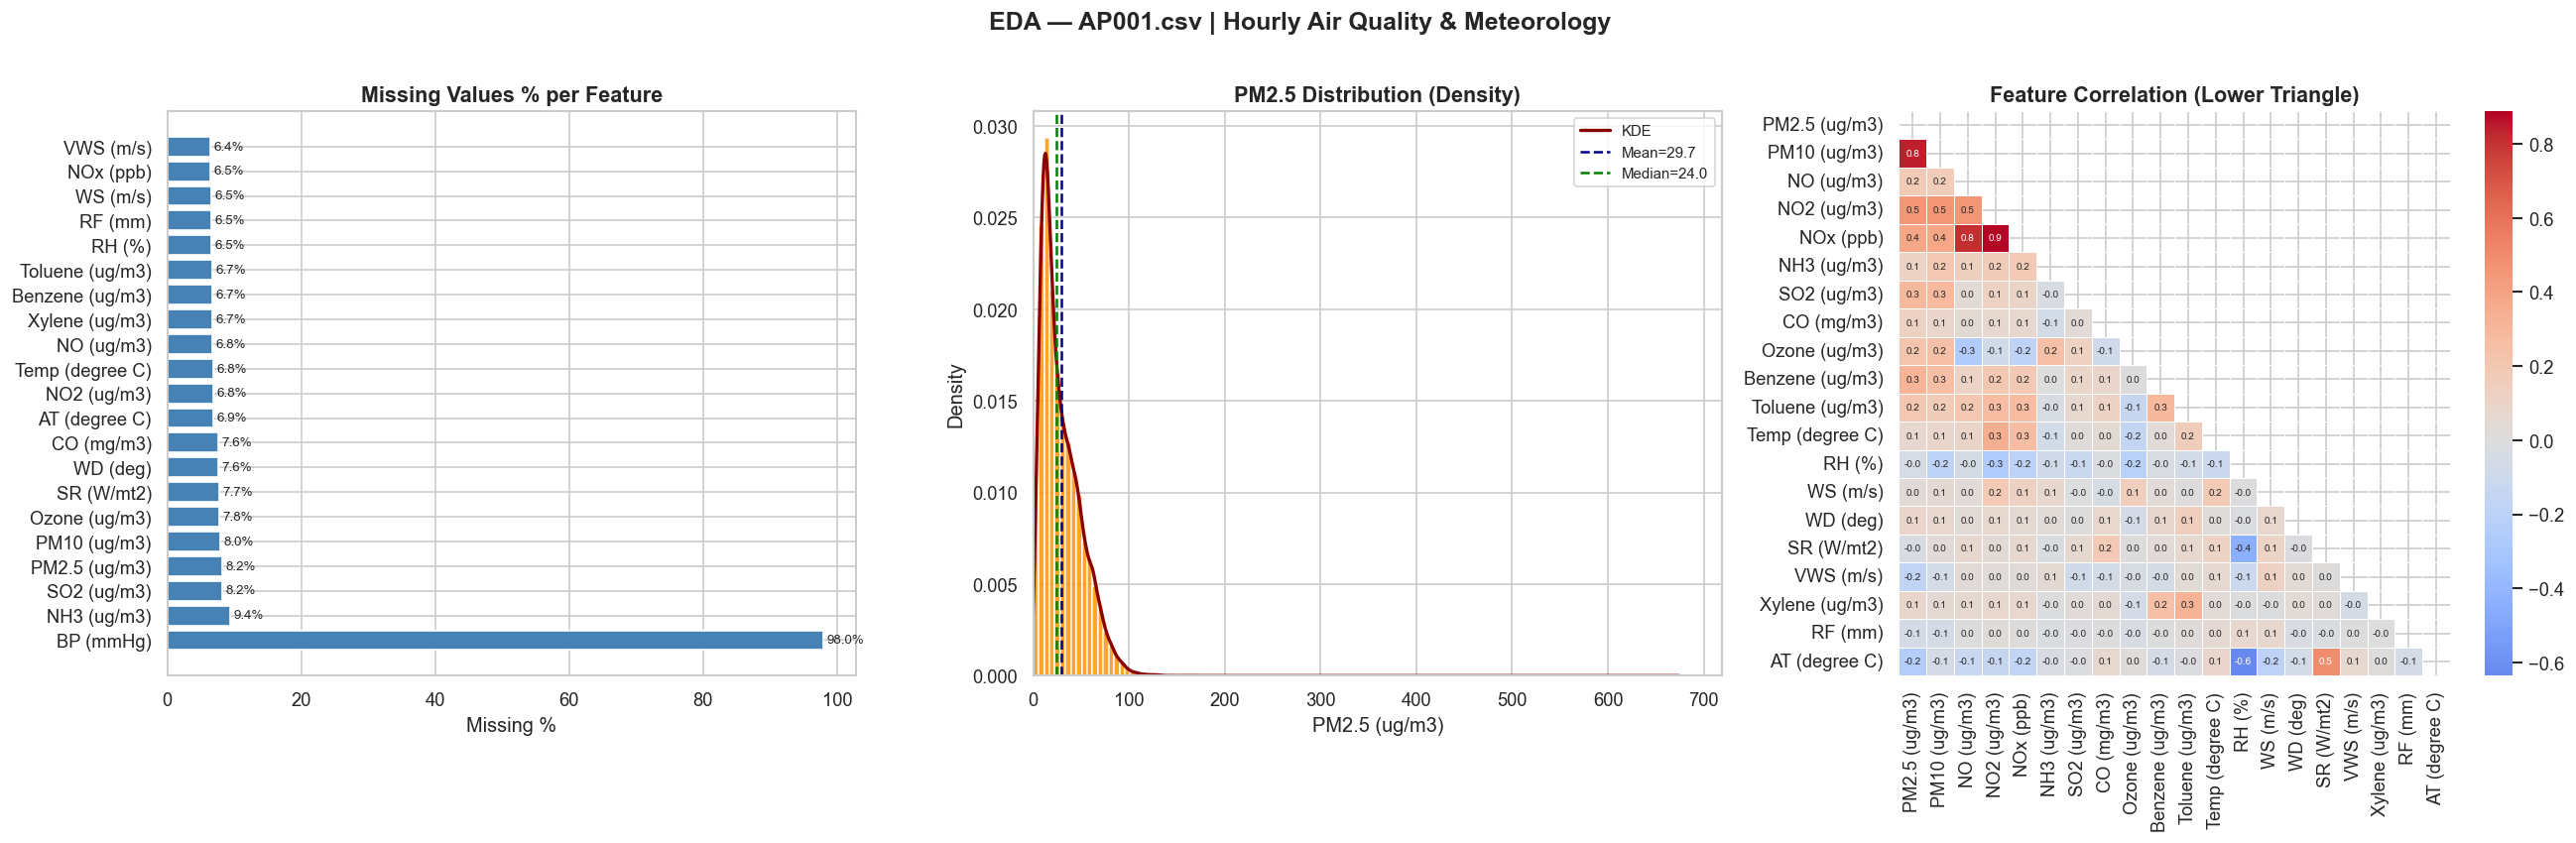

In [6]:
# ── EDA Figure 1: Missing % + PM2.5 Distribution + Correlation Heatmap ───────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Missing value bar chart ---
miss_plot = miss_df[miss_df['Missing %'] > 0]
bars = axes[0].barh(miss_plot.index, miss_plot['Missing %'],
                    color='steelblue', edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.1f}%', va='center', fontsize=8)
axes[0].set_title('Missing Values % per Feature', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Missing %')

# --- PM2.5 distribution with KDE ---
pm_valid = df_raw['PM2.5 (ug/m3)'].dropna()
axes[1].hist(pm_valid, bins=80, color='darkorange', edgecolor='white', density=True, alpha=0.8)
pm_valid.plot(kind='kde', ax=axes[1], color='darkred', lw=2, label='KDE')
axes[1].axvline(pm_valid.mean(),   color='navy',  linestyle='--', lw=1.5,
                label=f'Mean={pm_valid.mean():.1f}')
axes[1].axvline(pm_valid.median(), color='green', linestyle='--', lw=1.5,
                label=f'Median={pm_valid.median():.1f}')
axes[1].set_title('PM2.5 Distribution (Density)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PM2.5 (ug/m3)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0)

# --- Correlation heatmap (lower triangle) ---
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
# Drop BP (98% missing) from heatmap
num_cols = [c for c in num_cols if 'BP' not in c]
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[2], cmap='coolwarm', center=0, annot=True,
            fmt='.1f', linewidths=0.3, annot_kws={'size': 6}, mask=mask)
axes[2].set_title('Feature Correlation (Lower Triangle)', fontsize=13, fontweight='bold')

plt.suptitle('EDA — AP001.csv | Hourly Air Quality & Meteorology', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'eda_overview.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\eda_pm25_temporal.png


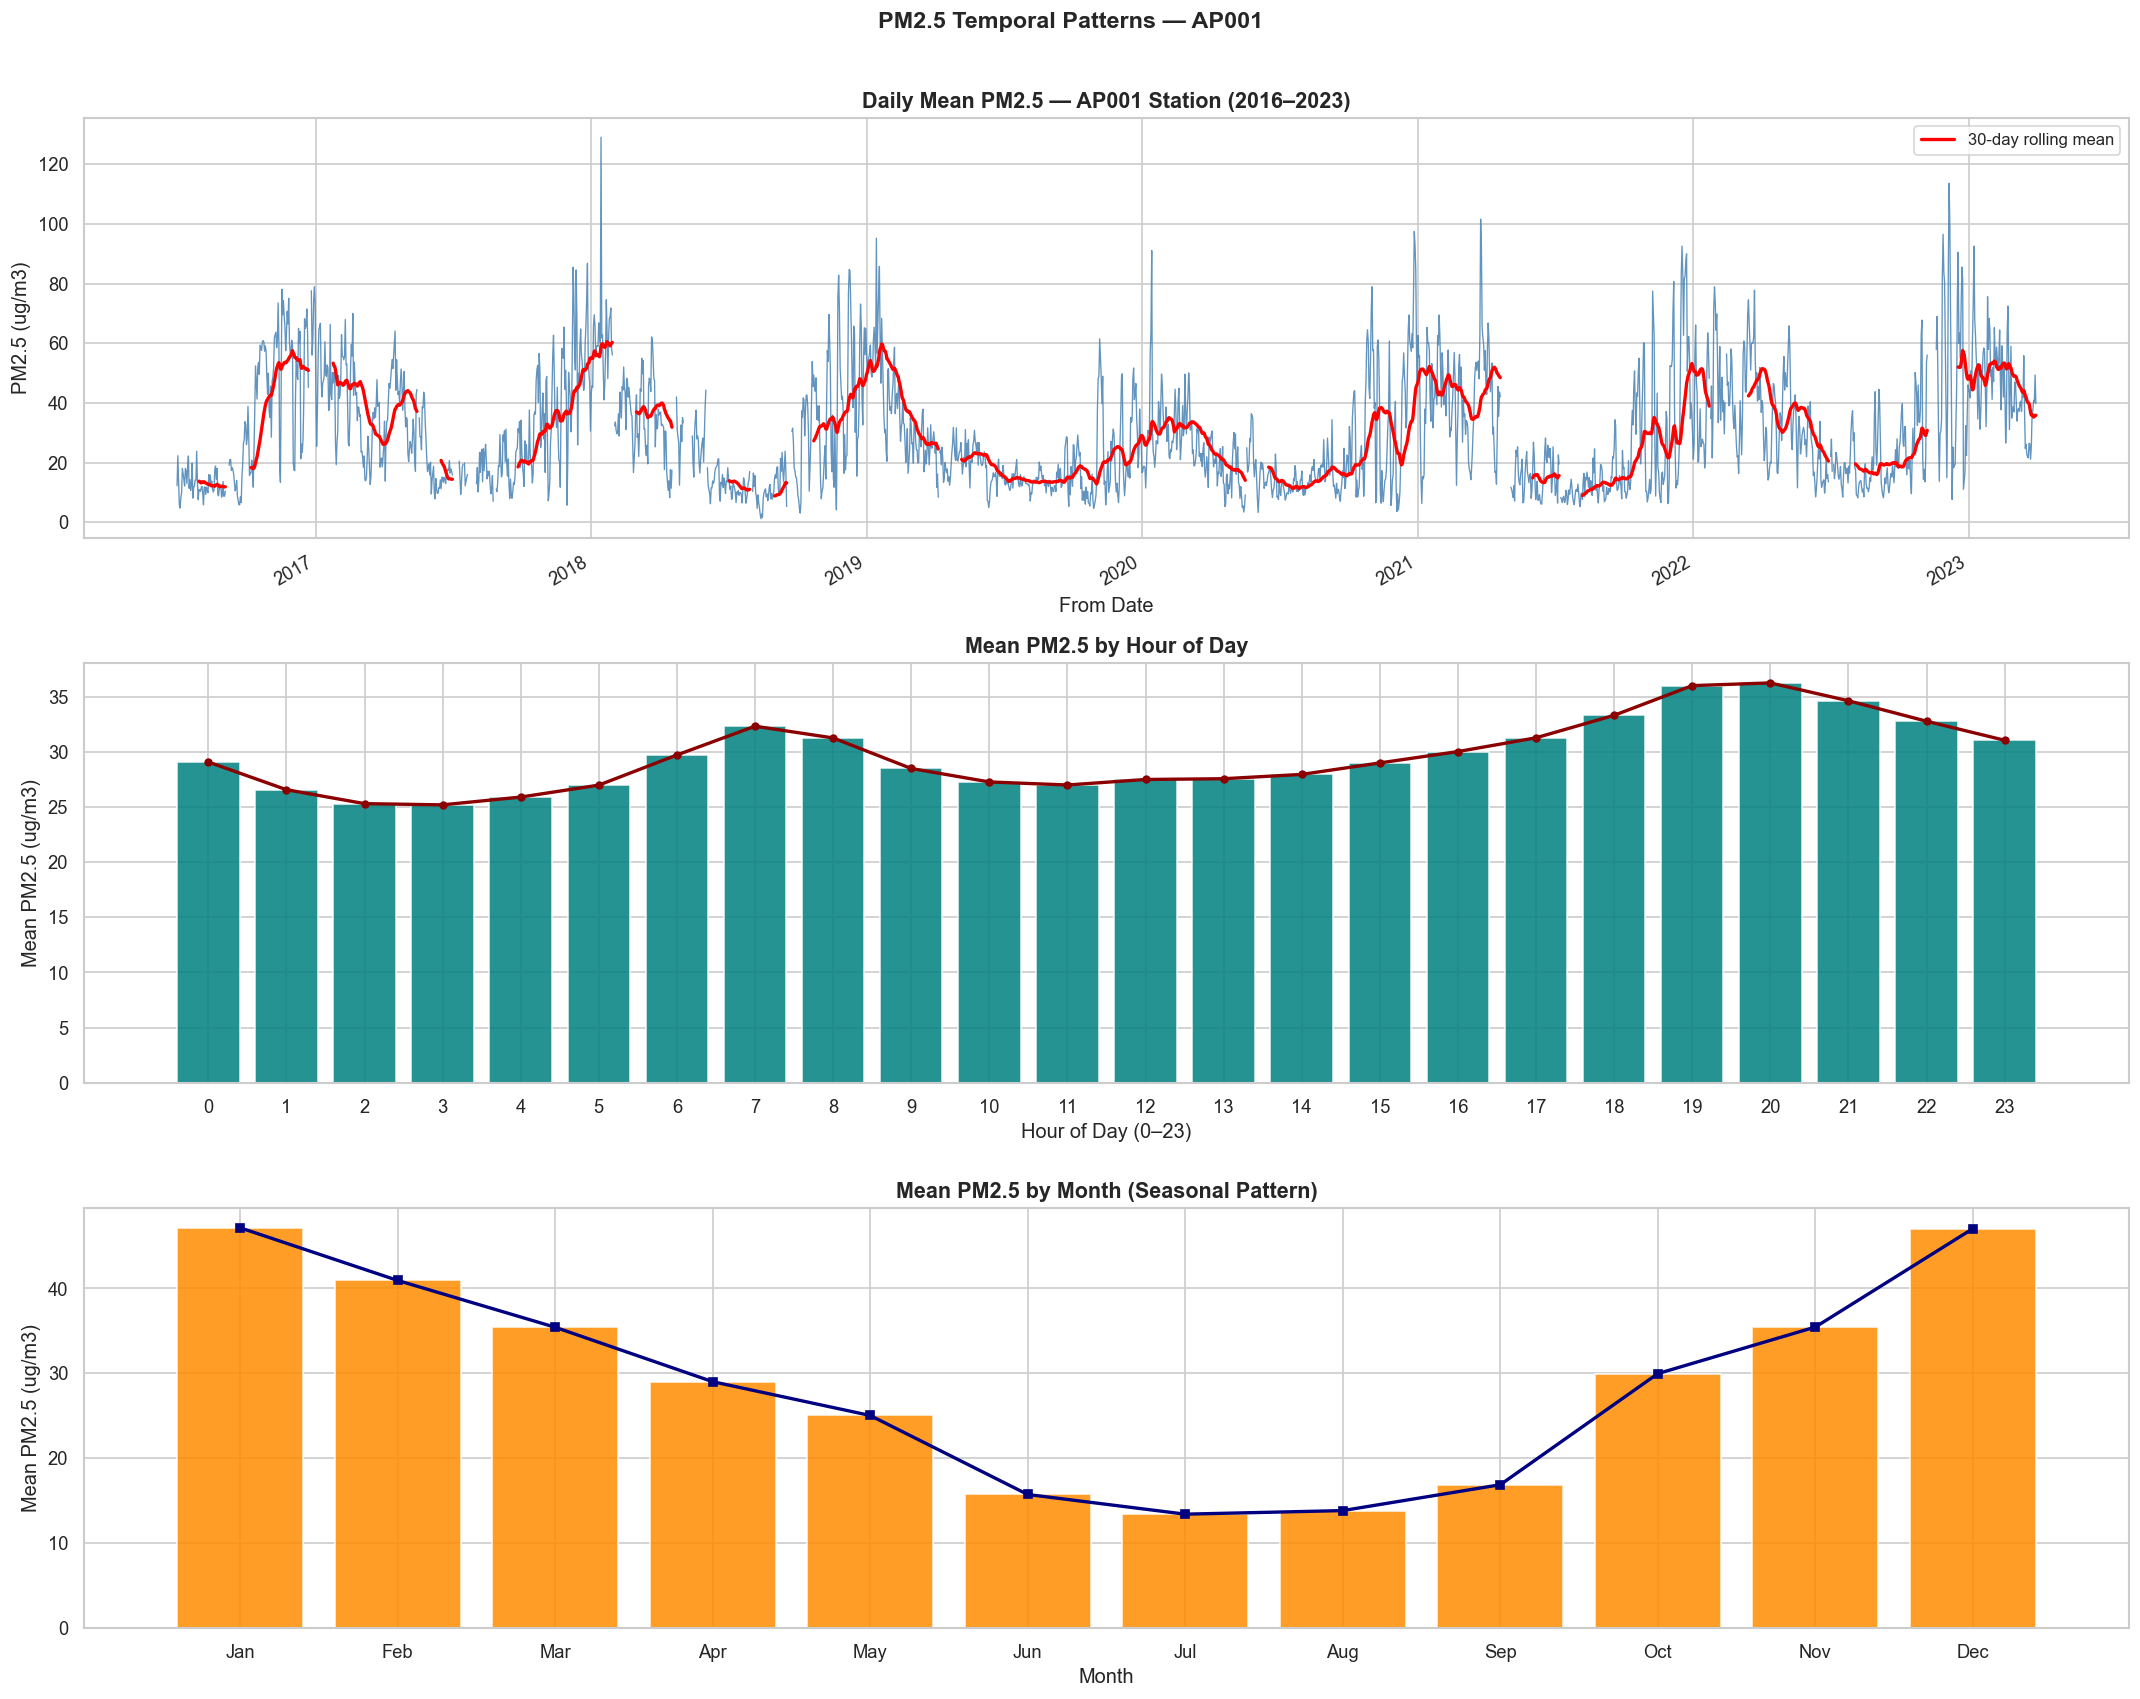

In [7]:
# ── EDA Figure 2: PM2.5 time-series + hourly & monthly patterns ───────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# --- Daily mean PM2.5 time-series ---
daily = df_raw.set_index('From Date')['PM2.5 (ug/m3)'].resample('D').mean()
axes[0].plot(daily.index, daily.values, color='steelblue', lw=0.8, alpha=0.85)
daily.rolling(30).mean().plot(ax=axes[0], color='red', lw=2, label='30-day rolling mean')
axes[0].set_title('Daily Mean PM2.5 — AP001 Station (2016–2023)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].legend(fontsize=10)

# --- Hourly pattern (mean PM2.5 by hour of day) ---
df_raw['Hour'] = df_raw['From Date'].dt.hour
hourly_pm = df_raw.groupby('Hour')['PM2.5 (ug/m3)'].mean()
axes[1].bar(hourly_pm.index, hourly_pm.values, color='teal', edgecolor='white', alpha=0.85)
axes[1].plot(hourly_pm.index, hourly_pm.values, color='darkred', lw=2, marker='o', ms=4)
axes[1].set_title('Mean PM2.5 by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0–23)')
axes[1].set_ylabel('Mean PM2.5 (ug/m3)')
axes[1].set_xticks(range(0, 24))

# --- Monthly pattern (mean PM2.5 by month) ---
df_raw['Month'] = df_raw['From Date'].dt.month
month_pm = df_raw.groupby('Month')['PM2.5 (ug/m3)'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_pm.index, month_pm.values, color='darkorange', edgecolor='white', alpha=0.85)
axes[2].plot(month_pm.index, month_pm.values, color='navy', lw=2, marker='s', ms=5)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_names)
axes[2].set_title('Mean PM2.5 by Month (Seasonal Pattern)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean PM2.5 (ug/m3)')

plt.suptitle('PM2.5 Temporal Patterns — AP001', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'eda_pm25_temporal.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\eda_scatter_pm25.png


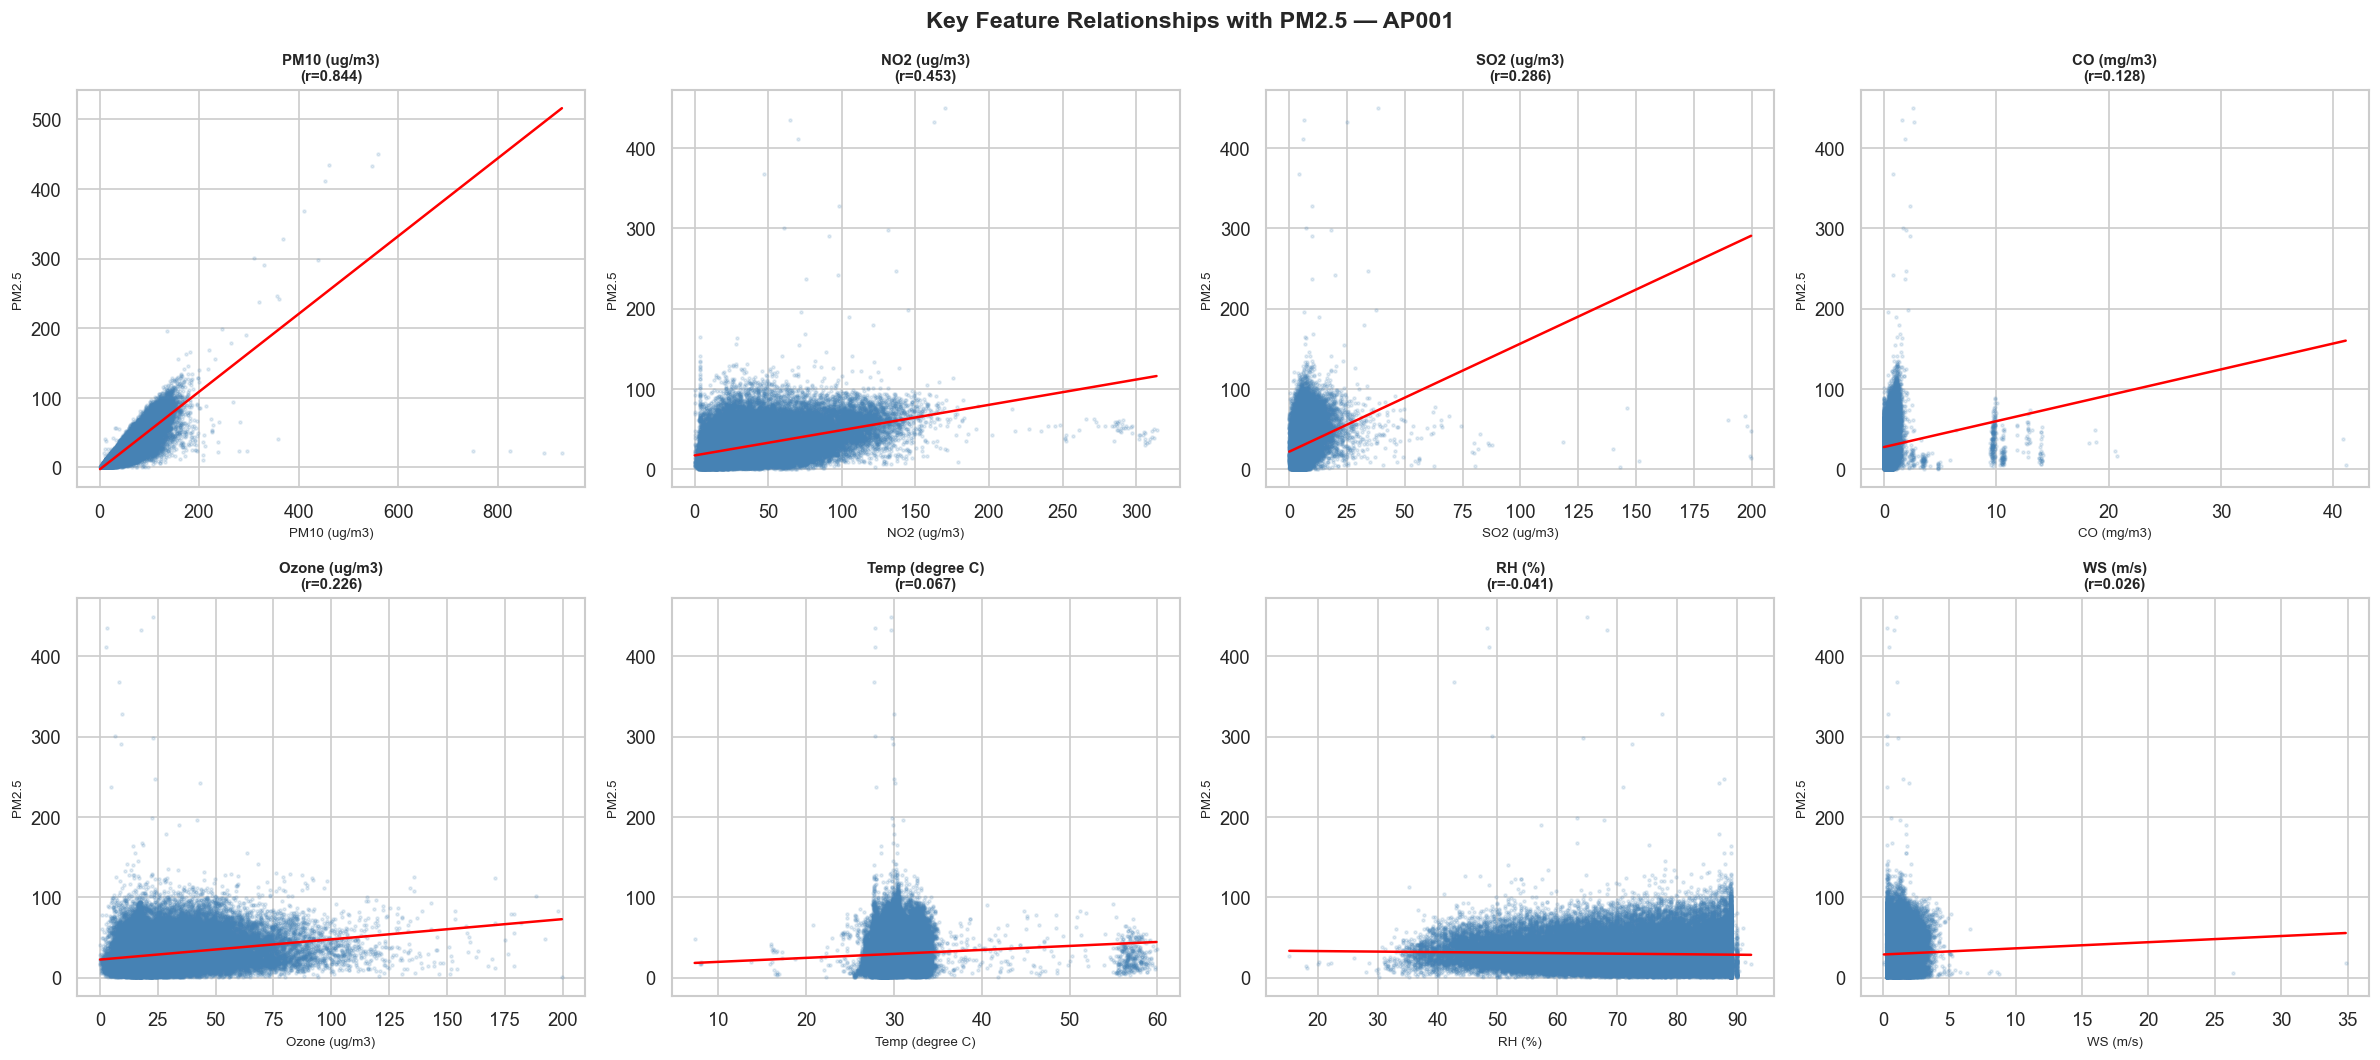

In [8]:
# ── EDA Figure 3: Pollutant pair-plots vs PM2.5 ───────────────────────────────
key_features = ['PM10 (ug/m3)', 'NO2 (ug/m3)', 'SO2 (ug/m3)',
                'CO (mg/m3)', 'Ozone (ug/m3)', 'Temp (degree C)',
                'RH (%)', 'WS (m/s)']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sub = df_raw[[feat, 'PM2.5 (ug/m3)']].dropna()
    axes[i].scatter(sub[feat], sub['PM2.5 (ug/m3)'],
                    alpha=0.15, s=3, color='steelblue')
    # Trend line
    z = np.polyfit(sub[feat], sub['PM2.5 (ug/m3)'], 1)
    p_fit = np.poly1d(z)
    xs = np.linspace(sub[feat].min(), sub[feat].max(), 100)
    axes[i].plot(xs, p_fit(xs), color='red', lw=1.5)
    corr_val = sub.corr().iloc[0, 1]
    axes[i].set_title(f'{feat}\n(r={corr_val:.3f})', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('PM2.5', fontsize=8)

plt.suptitle('Key Feature Relationships with PM2.5 — AP001', fontsize=14, fontweight='bold')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'eda_scatter_pm25.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

## Step 5: Feature Engineering & Preprocessing

**Actions:**
- Parse `From Date` → `Year`, `Month`, `Day`, `Hour`, `DayOfWeek`, `WeekOfYear`, `Quarter`
- Add lag features: `PM2.5_lag1h`, `PM2.5_lag3h`, `PM2.5_lag24h` (previous hour/day values)
- Add rolling window features: `PM2.5_roll3h_mean`, `PM2.5_roll6h_mean`
- Drop `To Date`, `From Date`, and `BP (mmHg)` (98% missing — unusable)
- Drop rows where target `PM2.5 (ug/m3)` is missing

In [9]:
df = df_raw.copy()

# ── 5.1  Temporal features from From Date ────────────────────────────────────
df['Year']       = df['From Date'].dt.year
df['Month']      = df['From Date'].dt.month
df['Day']        = df['From Date'].dt.day
df['Hour']       = df['From Date'].dt.hour
df['DayOfWeek']  = df['From Date'].dt.dayofweek
df['WeekOfYear'] = df['From Date'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['From Date'].dt.quarter
print('✅ Temporal features added: Year, Month, Day, Hour, DayOfWeek, WeekOfYear, Quarter')

# ── 5.2  Lag features (PM2.5 from previous hours) ────────────────────────────
# Sort by time first to ensure correct lag computation
df = df.sort_values('From Date').reset_index(drop=True)
df['PM2.5_lag1h']  = df['PM2.5 (ug/m3)'].shift(1)
df['PM2.5_lag3h']  = df['PM2.5 (ug/m3)'].shift(3)
df['PM2.5_lag24h'] = df['PM2.5 (ug/m3)'].shift(24)
print('✅ Lag features added: PM2.5_lag1h, PM2.5_lag3h, PM2.5_lag24h')

# ── 5.3  Rolling window features ──────────────────────────────────────────────
df['PM2.5_roll3h_mean']  = df['PM2.5 (ug/m3)'].shift(1).rolling(3).mean()
df['PM2.5_roll6h_mean']  = df['PM2.5 (ug/m3)'].shift(1).rolling(6).mean()
df['PM2.5_roll24h_std']  = df['PM2.5 (ug/m3)'].shift(1).rolling(24).std()
print('✅ Rolling features added: roll3h_mean, roll6h_mean, roll24h_std')

# ── 5.4  Drop unusable / leakage columns ─────────────────────────────────────
DROP_COLS = ['From Date', 'To Date', 'BP (mmHg)']   # BP = 98% missing
df.drop(columns=DROP_COLS, errors='ignore', inplace=True)
print(f'✅ Dropped: {DROP_COLS}')

# ── 5.5  Define TARGET and FEATURE columns ────────────────────────────────────
TARGET       = 'PM2.5 (ug/m3)'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

# ── 5.6  Drop rows where target is missing ────────────────────────────────────
df_clean = df.dropna(subset=[TARGET]).reset_index(drop=True)
X_raw    = df_clean[FEATURE_COLS]
y        = df_clean[TARGET].values.astype(np.float32)

print(f'\nFeature columns ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)
print(f'\nX shape : {X_raw.shape}')
print(f'y shape : {y.shape}')
print(f'y — mean={y.mean():.2f}  std={y.std():.2f}  min={y.min():.2f}  max={y.max():.2f}')

# Save cleaned pre-imputation data → data/processed/
clean_path = os.path.join(DATA_PROCESSED, 'AP001_cleaned.csv')
df_clean.to_csv(clean_path, index=False)
print(f'\nSaved: {clean_path}')

df_full = df.copy()   # keep full df (with NaN features) for SLM imputation

✅ Temporal features added: Year, Month, Day, Hour, DayOfWeek, WeekOfYear, Quarter
✅ Lag features added: PM2.5_lag1h, PM2.5_lag3h, PM2.5_lag24h
✅ Rolling features added: roll3h_mean, roll6h_mean, roll24h_std
✅ Dropped: ['From Date', 'To Date', 'BP (mmHg)']

Feature columns (32):
['PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'VWS (m/s)', 'Xylene (ug/m3)', 'RF (mm)', 'AT (degree C)', 'Hour', 'Month', 'Year', 'Day', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'PM2.5_lag1h', 'PM2.5_lag3h', 'PM2.5_lag24h', 'PM2.5_roll3h_mean', 'PM2.5_roll6h_mean', 'PM2.5_roll24h_std']

X shape : (54323, 32)
y shape : (54323,)
y — mean=29.72  std=21.37  min=0.25  max=449.50

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\processed\AP001_cleaned.csv


## Step 6: Traditional Imputation (Median) → `data/processed/`

Median imputation fills each missing feature cell with the **column median** — simple, fast, and robust to outliers.

In [10]:
# ── 6.1  Median imputation on feature columns ─────────────────────────────────
imputer  = SimpleImputer(strategy='median')
X_imp    = imputer.fit_transform(X_raw)
print(f'Any NaN after median imputation : {np.isnan(X_imp).any()}')

# ── 6.2  Save median-imputed dataset → data/processed/ ───────────────────────
df_median_save         = pd.DataFrame(X_imp, columns=FEATURE_COLS)
df_median_save[TARGET] = y
median_path = os.path.join(DATA_PROCESSED, 'AP001_median_imputed.csv')
df_median_save.to_csv(median_path, index=False)
print(f'Saved: {median_path}')

# ── 6.3  StandardScale (mean=0, std=1) ───────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# ── 6.4  Train / Val / Test split  70 / 15 / 15 ──────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

n_features = X_train.shape[1]
print(f'\nSplit — Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'n_features : {n_features}')

Any NaN after median imputation : False
Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\data\processed\AP001_median_imputed.csv

Split — Train: 38,026  Val: 8,148  Test: 8,149
n_features : 32


## Step 7: TabM Architecture

**TabM** (Tabular Multi-head MLP) creates **k independent MLP parameter copies** per sample and fuses them via mean-pooling — giving ensemble-level expressiveness at a fraction of the inference cost.

```
Input x ∈ ℝᶠ
  └─► EmbeddingBlock : Linear → BatchNorm → GELU → Dropout  →  h ∈ ℝᵈ
        └─► Expand to k copies  →  (B, k, d)
              └─► k × TabMBlock (shared Linear + per-copy bias + residual)
                    └─► Mean-pool across k copies  →  (B, d)
                          └─► Head : LayerNorm → Linear → GELU → Linear  →  PM2.5 scalar
```

| Hyperparameter | Value | Meaning |
|----------------|-------|---------|
| `d_embedding`  | 64    | Hidden width of each layer |
| `n_blocks`     | 3     | Number of residual MLP blocks |
| `k`            | 8     | Ensemble copies |
| `dropout`      | 0.1   | Dropout rate inside each block |

In [11]:
# =============================================================================
# TabM — Tabular Multi-head MLP
# Reference: Gorishniy et al. (2024) "TabM: Advancing Tabular Deep Learning
#            with Parameter-Efficient Ensembling"
# =============================================================================

class TabMEmbedding(nn.Module):
    """Projects raw input x ∈ R^F → embedding h ∈ R^d via Linear+BN+GELU."""
    def __init__(self, n_features: int, d_embedding: int, dropout: float = 0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(n_features, d_embedding),
            nn.BatchNorm1d(d_embedding),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)   # (B, F) → (B, d)


class TabMBlock(nn.Module):
    """Residual block with shared Linear weight and per-copy learned bias."""
    def __init__(self, d: int, k: int, dropout: float = 0.1):
        super().__init__()
        self.linear  = nn.Linear(d, d, bias=False)   # shared across k copies
        self.bias_k  = nn.Parameter(torch.zeros(k, d))
        nn.init.normal_(self.bias_k, std=0.01)
        self.bn      = nn.BatchNorm1d(d)
        self.act     = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        B, k, d = h.shape
        out = self.linear(h.view(B * k, d)).view(B, k, d)
        out = out + self.bias_k.unsqueeze(0)                  # per-copy bias
        out = self.bn(out.view(B * k, d)).view(B, k, d)
        out = self.act(out)
        out = self.dropout(out)
        return h + out                                         # residual


class TabM(nn.Module):
    """Full TabM model for tabular regression."""
    def __init__(self, n_features: int, d_embedding: int = 64,
                 n_blocks: int = 3, k: int = 8, dropout: float = 0.1):
        super().__init__()
        self.k         = k
        self.embedding = TabMEmbedding(n_features, d_embedding, dropout)
        self.blocks    = nn.ModuleList(
            [TabMBlock(d_embedding, k, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.LayerNorm(d_embedding),
            nn.Linear(d_embedding, d_embedding // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_embedding // 2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.embedding(x)                            # (B, d)
        h = h.unsqueeze(1).expand(-1, self.k, -1).contiguous()  # (B, k, d)
        for block in self.blocks:
            h = block(h)
        h = h.mean(dim=1)                                # (B, d)  — mean pool
        return self.head(h).squeeze(1)                   # (B,)


# ── Sanity check ─────────────────────────────────────────────────────────────
_dummy = torch.randn(4, 10)
_model = TabM(n_features=10, d_embedding=32, n_blocks=2, k=4)
_out   = _model(_dummy)
assert _out.shape == (4,), f'Unexpected shape: {_out.shape}'
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'TabM sanity check passed — output shape: {_out.shape}')
print(f'TabM (demo: 10-feat, d=32, k=4) — {total_params:,} parameters')
del _dummy, _model, _out

TabM sanity check passed — output shape: torch.Size([4])
TabM (demo: 10-feat, d=32, k=4) — 3,457 parameters


## Step 8: Training & Evaluation Utilities → `logs/`

In [12]:
def make_loader(X, y, batch_size=256, shuffle=True):
    """Wrap numpy arrays into a PyTorch DataLoader."""
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_tabm(model, X_tr, y_tr, X_val, y_val,
               epochs=150, lr=1e-3, batch_size=256, patience=20, label=''):
    """
    Train TabM with AdamW + CosineAnnealingLR + early stopping.
    Saves log → logs/training_log_{label}.txt
    Returns (best_model, history_dict).
    """
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.HuberLoss()     # robust to PM2.5 outliers (max=449)
    loader    = make_loader(X_tr, y_tr, batch_size)

    best_val_rmse = float('inf')
    best_state    = None
    no_improve    = 0
    history       = {'train_loss': [], 'val_rmse': []}
    log_lines     = []

    for epoch in range(1, epochs + 1):
        # ── Training phase ───────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        # ── Validation phase ─────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_pred = model(torch.FloatTensor(X_val).to(DEVICE)).cpu().numpy()
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

        history['train_loss'].append(epoch_loss / len(loader))
        history['val_rmse'].append(val_rmse)

        if epoch % 25 == 0 or epoch == 1:
            log = (f'  [{label}] Epoch {epoch:3d}/{epochs} | '
                   f'Loss={epoch_loss/len(loader):.4f} | '
                   f'Val RMSE={val_rmse:.4f} | Best={best_val_rmse:.4f}')
            print(log)
            log_lines.append(log)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                msg = f'  Early stop at epoch {epoch}  (best val RMSE={best_val_rmse:.4f})'
                print(msg); log_lines.append(msg)
                break

    # ── Save training log → logs/ ─────────────────────────────────────────────
    log_path = os.path.join(LOGS_DIR, f'training_log_{label}.txt')
    with open(log_path, 'w') as f:
        f.write('\n'.join(log_lines))
    print(f'  Log saved : {log_path}')

    model.load_state_dict(best_state)
    return model, history


def predict_tabm(model, X):
    """Run inference; return 1-D numpy array."""
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(X).to(DEVICE)).cpu().numpy()


# ── Global results accumulator ────────────────────────────────────────────────
results = []

def evaluate(name, imputation, y_true, y_pred):
    """Compute RMSE / MAE / R² and append to results."""
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    entry = {'Model': name, 'Imputation': imputation,
             'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R2': round(r2, 4)}
    results.append(entry)
    print(f'{name:25s} | {imputation:10s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return entry

print('Training & evaluation utilities ready.')

Training & evaluation utilities ready.


## Step 9: Train TabM — Traditional (Median) Imputation → `models/`, `logs/`

In [13]:
print('Training TabM on Median-imputed data...')
print(f'  n_features={n_features}  d_embedding=64  n_blocks=3  k=8  dropout=0.1')
print('-' * 65)

tabm_trad    = TabM(n_features=n_features, d_embedding=64, n_blocks=3, k=8, dropout=0.1)
total_params = sum(p.numel() for p in tabm_trad.parameters() if p.requires_grad)
print(f'  Total trainable parameters : {total_params:,}')

tabm_trad, history_trad = train_tabm(
    tabm_trad, X_train, y_train, X_val, y_val,
    epochs=150, lr=1e-3, patience=20, label='AP001_Median')

preds_trad = predict_tabm(tabm_trad, X_test)
evaluate('TabM', 'Median', y_test, preds_trad)

# ── Save model weights → models/ ─────────────────────────────────────────────
model_path_trad = os.path.join(MODELS_DIR, 'AP001_tabm_median.pt')
torch.save(tabm_trad.state_dict(), model_path_trad)
print(f'Saved: {model_path_trad}')

Training TabM on Median-imputed data...
  n_features=32  d_embedding=64  n_blocks=3  k=8  dropout=0.1
-----------------------------------------------------------------
  Total trainable parameters : 18,689
  [AP001_Median] Epoch   1/150 | Loss=20.4403 | Val RMSE=14.7588 | Best=inf
  [AP001_Median] Epoch  25/150 | Loss=3.9224 | Val RMSE=4.9491 | Best=4.9259
  [AP001_Median] Epoch  50/150 | Loss=3.7042 | Val RMSE=4.8004 | Best=4.7731
  [AP001_Median] Epoch  75/150 | Loss=3.5786 | Val RMSE=4.7283 | Best=4.7241
  Early stop at epoch 93  (best val RMSE=4.7241)
  Log saved : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\logs\training_log_AP001_Median.txt
TabM                      | Median     | RMSE=6.0000  MAE=3.4163  R2=0.9223
Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\models\AP001_tabm_median.pt


## Step 10: SLM-Based Imputation (RandomForest) → `data/processed/`

For each feature column with missing values (sorted least-missing first):
1. Use all **other** feature columns (temporarily median-filled) as predictors.
2. Train a `RandomForestRegressor` on rows where the target column **is present**.
3. Predict and fill the missing values.
4. Each subsequent column benefits from a more complete dataset.

In [14]:
def slm_impute(df_in, target_col=TARGET, seed=SEED):
    """
    SLM-based (RandomForest) iterative imputation.
    Columns sorted by ascending missing % so cleaner columns are imputed first.
    Saves to data/processed/ automatically.
    """
    df_imp    = df_in.copy()
    feat_cols = [c for c in df_imp.columns if c != target_col]

    missing_pct = {c: df_imp[c].isnull().mean() for c in feat_cols}
    cols_sorted = sorted(feat_cols, key=lambda c: missing_pct[c])

    for col in cols_sorted:
        missing_mask = df_imp[col].isnull()
        n_miss = missing_mask.sum()
        if n_miss == 0:
            continue

        other_cols = [c for c in feat_cols if c != col]
        train_rows = df_imp[~missing_mask]
        pred_rows  = df_imp[missing_mask]

        sub_imp  = SimpleImputer(strategy='median')
        X_tr_sub = sub_imp.fit_transform(train_rows[other_cols])
        X_pr_sub = sub_imp.transform(pred_rows[other_cols])
        y_tr_sub = train_rows[col].values

        rf = RandomForestRegressor(n_estimators=50, random_state=seed, n_jobs=-1)
        rf.fit(X_tr_sub, y_tr_sub)
        df_imp.loc[missing_mask, col] = rf.predict(X_pr_sub)

        print(f'  Imputed {n_miss:6,} values in [{col:<30}]  '
              f'(missing={missing_pct[col]*100:.1f}%)')

    return df_imp


print('Running SLM-based (RandomForest) imputation on AP001 features...')
print('-' * 65)

df_slm = slm_impute(df_full)

print(f'\nAny NaN remaining in features : '
      f'{df_slm[FEATURE_COLS].isnull().values.any()}')

# ── Save SLM-imputed dataset → data/processed/ ────────────────────────────────
slm_path = os.path.join(DATA_PROCESSED, 'AP001_slm_imputed.csv')
df_slm.to_csv(slm_path, index=False)
print(f'Saved: {slm_path}')

Running SLM-based (RandomForest) imputation on AP001 features...
-----------------------------------------------------------------
  Imputed  3,809 values in [VWS (m/s)                     ]  (missing=6.4%)
  Imputed  3,835 values in [NOx (ppb)                     ]  (missing=6.5%)
  Imputed  3,851 values in [WS (m/s)                      ]  (missing=6.5%)
  Imputed  3,865 values in [RF (mm)                       ]  (missing=6.5%)
  Imputed  3,869 values in [RH (%)                        ]  (missing=6.5%)
  Imputed  3,937 values in [Benzene (ug/m3)               ]  (missing=6.7%)
  Imputed  3,937 values in [Toluene (ug/m3)               ]  (missing=6.7%)
  Imputed  3,950 values in [Xylene (ug/m3)                ]  (missing=6.7%)
  Imputed  3,997 values in [NO (ug/m3)                    ]  (missing=6.8%)
  Imputed  4,037 values in [Temp (degree C)               ]  (missing=6.8%)
  Imputed  4,050 values in [NO2 (ug/m3)                   ]  (missing=6.8%)
  Imputed  4,063 values in [AT (d

In [15]:
# ── Build train/val/test from SLM-imputed data ────────────────────────────────
df_slm_clean = df_slm.dropna(subset=[TARGET]).reset_index(drop=True)

X_slm_raw    = df_slm_clean[FEATURE_COLS].values.astype(np.float32)
y_slm        = df_slm_clean[TARGET].values.astype(np.float32)

# Use the SAME scaler fitted on median-imputed training data (avoids leakage)
X_slm_scaled = scaler.transform(X_slm_raw)

X_tr_s, X_tmp_s, y_tr_s, y_tmp_s = train_test_split(
    X_slm_scaled, y_slm, test_size=0.30, random_state=SEED)
X_val_s, X_te_s, y_val_s, y_te_s = train_test_split(
    X_tmp_s, y_tmp_s, test_size=0.50, random_state=SEED)

print(f'SLM split — Train: {len(X_tr_s):,}  Val: {len(X_val_s):,}  Test: {len(X_te_s):,}')

SLM split — Train: 38,026  Val: 8,148  Test: 8,149


## Step 11: Train TabM — SLM-Based Imputation → `models/`, `logs/`

In [16]:
print('Training TabM on SLM-imputed data...')
print(f'  n_features={X_tr_s.shape[1]}  d_embedding=64  n_blocks=3  k=8  dropout=0.1')
print('-' * 65)

tabm_slm = TabM(n_features=X_tr_s.shape[1], d_embedding=64, n_blocks=3, k=8, dropout=0.1)

tabm_slm, history_slm = train_tabm(
    tabm_slm, X_tr_s, y_tr_s, X_val_s, y_val_s,
    epochs=150, lr=1e-3, patience=20, label='AP001_SLM')

preds_slm = predict_tabm(tabm_slm, X_te_s)
evaluate('TabM', 'SLM', y_te_s, preds_slm)

# ── Save model weights → models/ ─────────────────────────────────────────────
model_path_slm = os.path.join(MODELS_DIR, 'AP001_tabm_slm.pt')
torch.save(tabm_slm.state_dict(), model_path_slm)
print(f'Saved: {model_path_slm}')

Training TabM on SLM-imputed data...
  n_features=32  d_embedding=64  n_blocks=3  k=8  dropout=0.1
-----------------------------------------------------------------
  [AP001_SLM] Epoch   1/150 | Loss=20.3972 | Val RMSE=13.9775 | Best=inf
  [AP001_SLM] Epoch  25/150 | Loss=3.7782 | Val RMSE=4.9357 | Best=4.7740
  [AP001_SLM] Epoch  50/150 | Loss=3.4917 | Val RMSE=4.7127 | Best=4.6636
  [AP001_SLM] Epoch  75/150 | Loss=3.4033 | Val RMSE=4.6528 | Best=4.6098
  [AP001_SLM] Epoch 100/150 | Loss=3.3538 | Val RMSE=4.6598 | Best=4.5676
  Early stop at epoch 107  (best val RMSE=4.5676)
  Log saved : c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\logs\training_log_AP001_SLM.txt
TabM                      | SLM        | RMSE=5.8173  MAE=3.3562  R2=0.9270
Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\models\AP001_tabm_slm.pt


## Step 12: Training Curve Plots → `results/`

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\AP001_tabm_training_curves.png


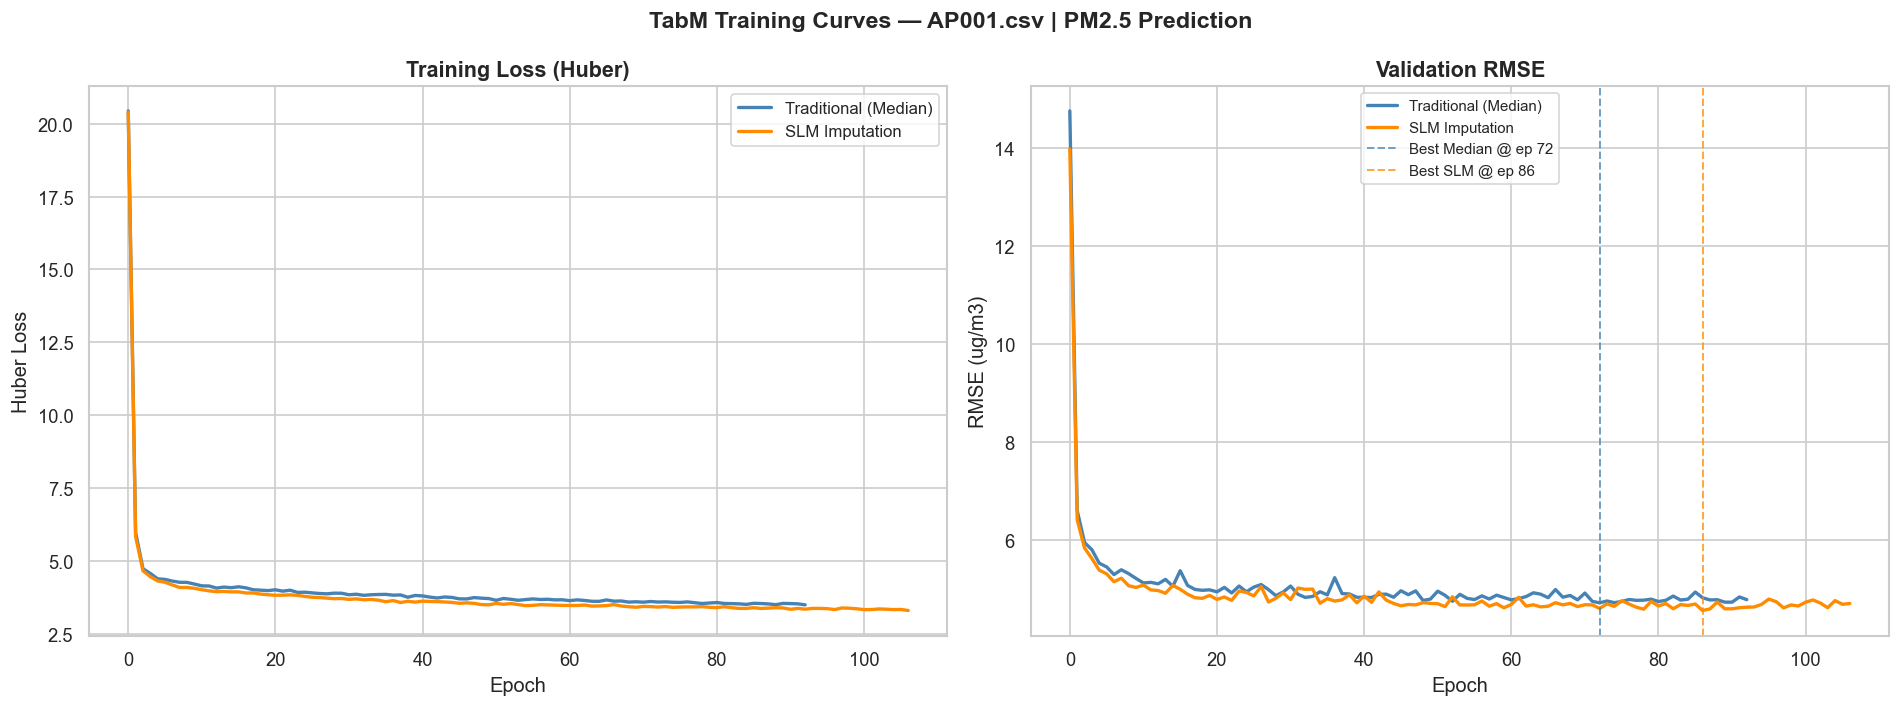

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Training Loss ─────────────────────────────────────────────────────────────
axes[0].plot(history_trad['train_loss'], label='Traditional (Median)', color='steelblue', lw=2)
axes[0].plot(history_slm['train_loss'],  label='SLM Imputation',       color='darkorange', lw=2)
axes[0].set_title('Training Loss (Huber)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend(fontsize=10)

# ── Validation RMSE ───────────────────────────────────────────────────────────
axes[1].plot(history_trad['val_rmse'], label='Traditional (Median)', color='steelblue', lw=2)
axes[1].plot(history_slm['val_rmse'],  label='SLM Imputation',       color='darkorange', lw=2)

best_trad_ep = int(np.argmin(history_trad['val_rmse']))
best_slm_ep  = int(np.argmin(history_slm['val_rmse']))
axes[1].axvline(best_trad_ep, color='steelblue',  ls='--', lw=1.2, alpha=0.75,
                label=f'Best Median @ ep {best_trad_ep}')
axes[1].axvline(best_slm_ep,  color='darkorange', ls='--', lw=1.2, alpha=0.75,
                label=f'Best SLM @ ep {best_slm_ep}')
axes[1].set_title('Validation RMSE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (ug/m3)')
axes[1].legend(fontsize=9)

plt.suptitle('TabM Training Curves — AP001.csv | PM2.5 Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'AP001_tabm_training_curves.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

## Step 13: Predicted vs Actual PM2.5 Plots → `results/`

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\AP001_tabm_pred_vs_actual.png


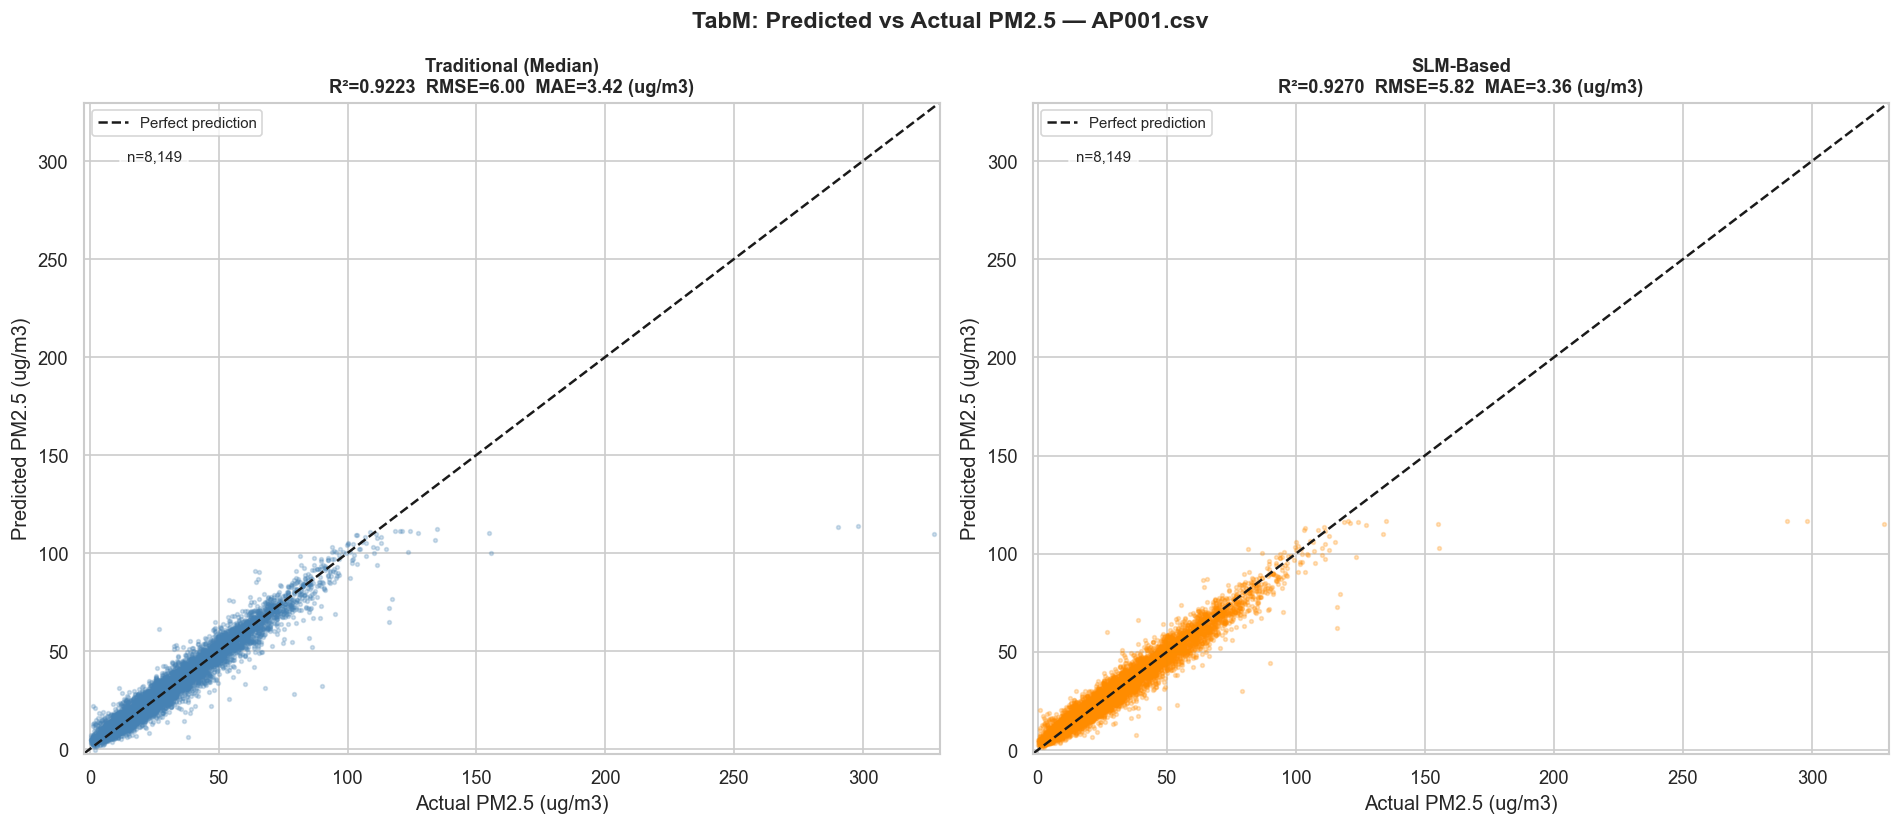

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, y_true, y_pred, title, color in [
    (axes[0], y_test,  preds_trad, 'Traditional (Median)', 'steelblue'),
    (axes[1], y_te_s,  preds_slm,  'SLM-Based',            'darkorange')
]:
    ax.scatter(y_true, y_pred, alpha=0.25, s=5, color=color)
    lims = [min(y_true.min(), y_pred.min()) - 2,
            max(y_true.max(), y_pred.max()) + 2]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    ax.set_title(f'{title}\nR²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f} (ug/m3)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual PM2.5 (ug/m3)')
    ax.set_ylabel('Predicted PM2.5 (ug/m3)')
    ax.legend(fontsize=9)
    ax.text(0.05, 0.91, f'n={len(y_true):,}', transform=ax.transAxes,
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle('TabM: Predicted vs Actual PM2.5 — AP001.csv',
             fontsize=14, fontweight='bold')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'AP001_tabm_pred_vs_actual.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

## Step 14: PM2.5 Distribution + Residual Plots → `results/`

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\AP001_tabm_pm25_distribution.png


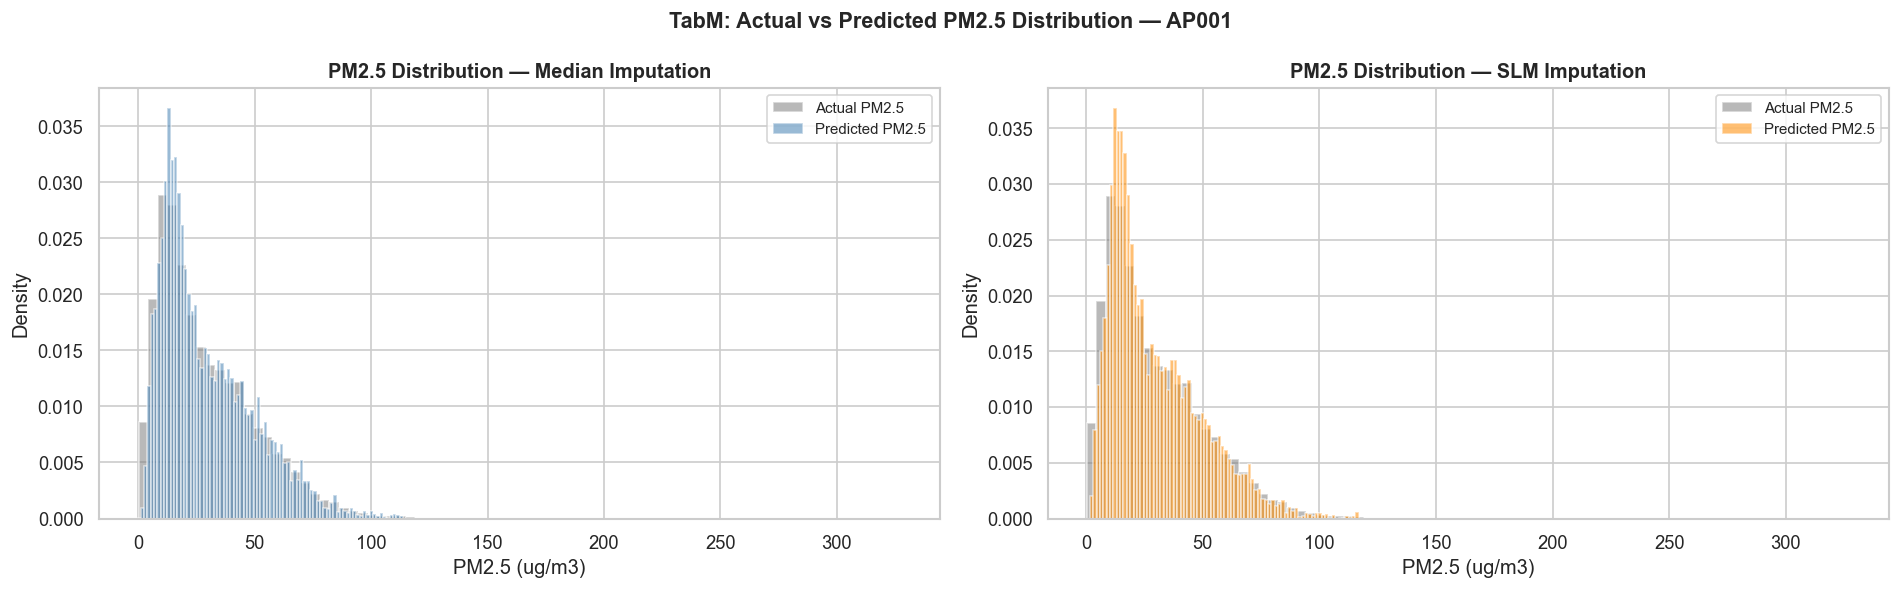

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\AP001_tabm_residuals.png


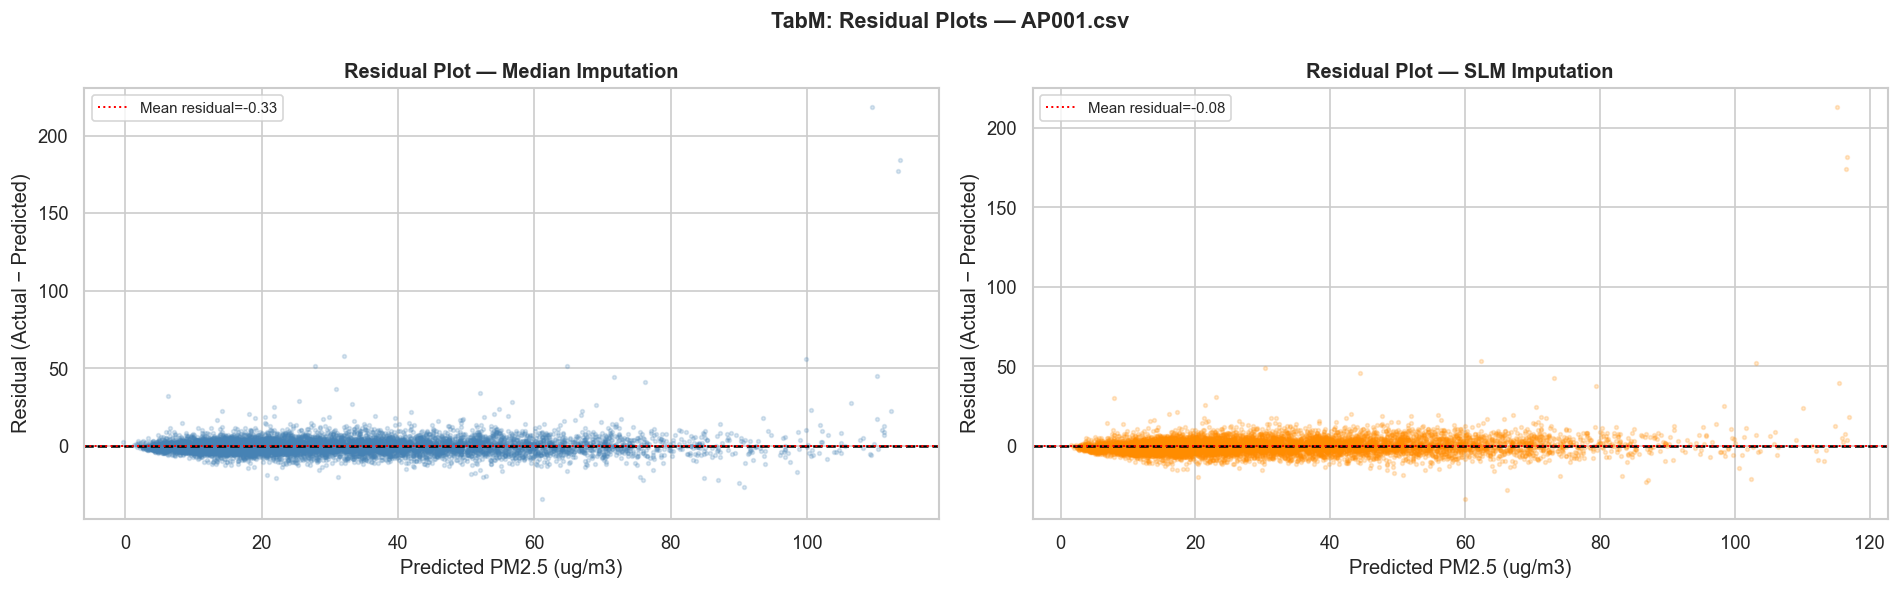

In [19]:
# ── Distribution overlays ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, y_true, y_pred, title, color in [
    (axes[0], y_test,  preds_trad, 'Median Imputation', 'steelblue'),
    (axes[1], y_te_s,  preds_slm,  'SLM Imputation',    'darkorange')
]:
    ax.hist(y_true, bins=80, alpha=0.55, label='Actual PM2.5',    color='gray',  density=True)
    ax.hist(y_pred, bins=80, alpha=0.55, label='Predicted PM2.5', color=color,   density=True)
    ax.set_title(f'PM2.5 Distribution — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PM2.5 (ug/m3)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('TabM: Actual vs Predicted PM2.5 Distribution — AP001',
             fontsize=13, fontweight='bold')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'AP001_tabm_pm25_distribution.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

# ── Residual plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, y_true, y_pred, title, color in [
    (axes[0], y_test,  preds_trad, 'Median Imputation', 'steelblue'),
    (axes[1], y_te_s,  preds_slm,  'SLM Imputation',    'darkorange')
]:
    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, s=5, color=color)
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.axhline(residuals.mean(), color='red', lw=1.2, linestyle=':',
               label=f'Mean residual={residuals.mean():.2f}')
    ax.set_title(f'Residual Plot — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted PM2.5 (ug/m3)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.legend(fontsize=9)

plt.suptitle('TabM: Residual Plots — AP001.csv', fontsize=13, fontweight='bold')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'AP001_tabm_residuals.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

## Step 15: Final Results & Comparison → `results/`

In [20]:
results_df = pd.DataFrame(results)

print('\n' + '='*65)
print('       FINAL RESULTS — TabM on AP001.csv  |  Target: PM2.5')
print('='*65)
print(results_df.to_string(index=False))

csv_out = os.path.join(RESULTS_DIR, 'AP001_tabm_results.csv')
results_df.to_csv(csv_out, index=False)
print(f'\nSaved: {csv_out}')

# ── Improvement summary ───────────────────────────────────────────────────────
trad_row   = results_df[results_df['Imputation'] == 'Median'].iloc[0]
slm_row    = results_df[results_df['Imputation'] == 'SLM'].iloc[0]
rmse_delta = trad_row['RMSE'] - slm_row['RMSE']
mae_delta  = trad_row['MAE']  - slm_row['MAE']
r2_delta   = slm_row['R2']    - trad_row['R2']

print('\n── Improvement (SLM over Median) ──')
print(f'  RMSE : {rmse_delta:+.4f} ug/m3  ({"✅ better" if rmse_delta > 0 else "⚠ worse"})')
print(f'  MAE  : {mae_delta:+.4f} ug/m3  ({"✅ better" if mae_delta  > 0 else "⚠ worse"})')
print(f'  R²   : {r2_delta:+.4f}        ({"✅ better" if r2_delta   > 0 else "⚠ worse"})')


       FINAL RESULTS — TabM on AP001.csv  |  Target: PM2.5
Model Imputation   RMSE    MAE     R2
 TabM     Median 6.0000 3.4163 0.9223
 TabM        SLM 5.8173 3.3562 0.9270

Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\AP001_tabm_results.csv

── Improvement (SLM over Median) ──
  RMSE : +0.1827 ug/m3  (✅ better)
  MAE  : +0.0601 ug/m3  (✅ better)
  R²   : +0.0047        (✅ better)


Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\AP001_tabm_comparison.png


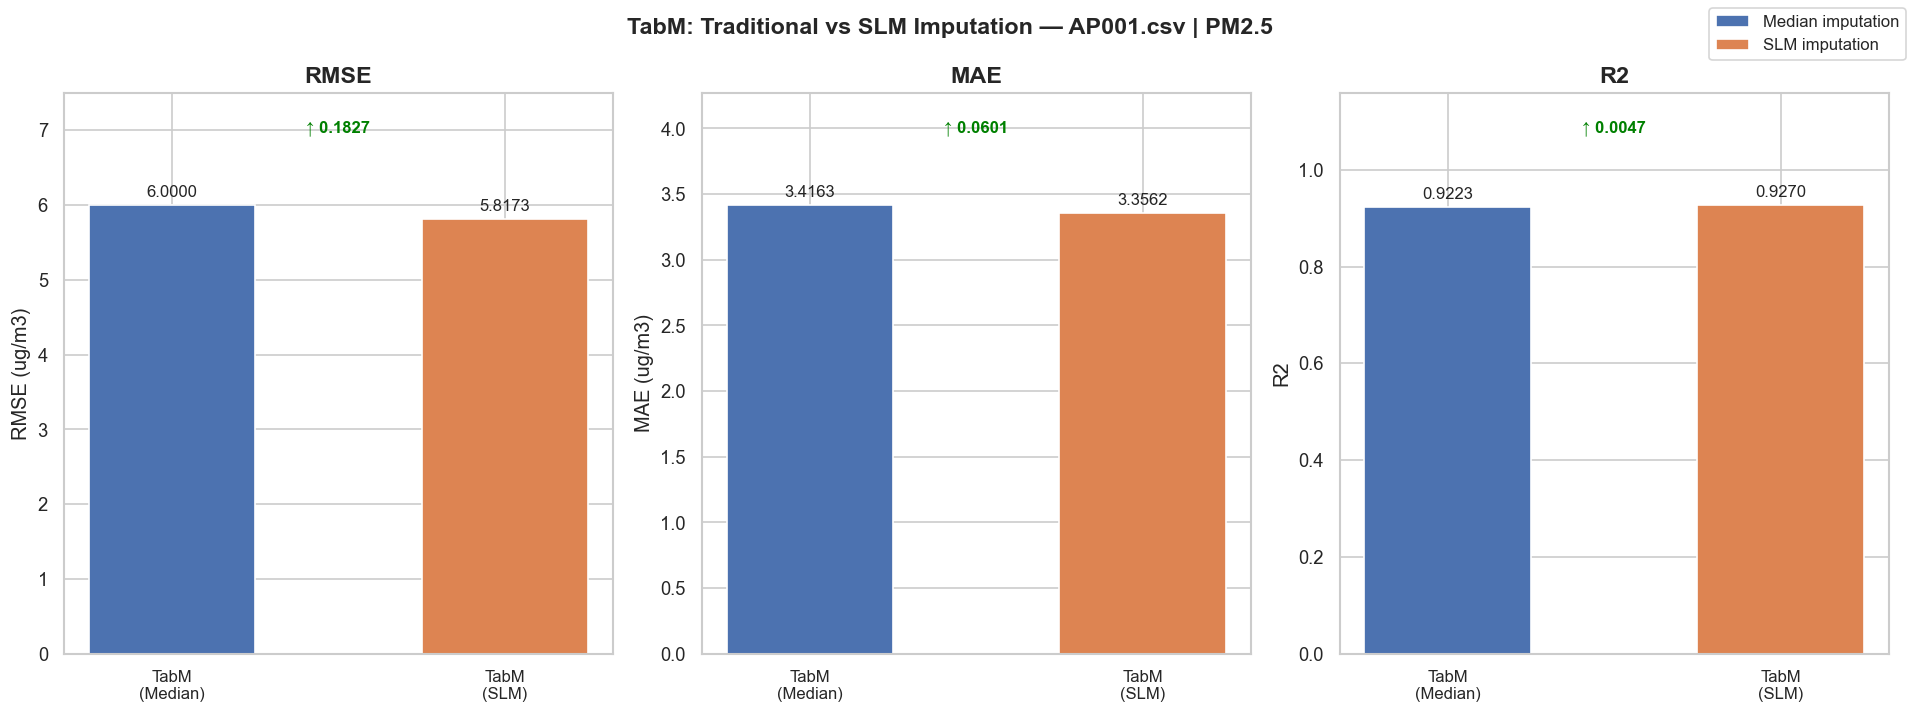

In [21]:
# ── Grouped comparison bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
palette   = {'Median': '#4C72B0', 'SLM': '#DD8452'}

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    colors_bar = [palette.get(i, 'gray') for i in results_df['Imputation']]
    labels     = results_df['Model'] + '\n(' + results_df['Imputation'] + ')'
    bars = ax.bar(labels, results_df[metric],
                  color=colors_bar, edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%.4f', fontsize=10, padding=3)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel(metric + (' (ug/m3)' if metric != 'R2' else ''))
    ax.set_ylim(0, results_df[metric].max() * 1.25)
    ax.tick_params(axis='x', labelsize=10)

    # Annotate delta
    vals  = results_df[metric].values
    delta = vals[0] - vals[1] if metric != 'R2' else vals[1] - vals[0]
    sign  = '↑' if delta > 0 else '↓'
    col   = 'green' if delta > 0 else 'red'
    ax.annotate(f'{sign} {abs(delta):.4f}', xy=(0.5, 0.93),
                xycoords='axes fraction', ha='center',
                fontsize=10, color=col, fontweight='bold')

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#4C72B0', label='Median imputation'),
    Patch(facecolor='#DD8452', label='SLM imputation')
], loc='upper right', fontsize=10)

plt.suptitle('TabM: Traditional vs SLM Imputation — AP001.csv | PM2.5',
             fontsize=14, fontweight='bold')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'AP001_tabm_comparison.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

## Step 16: Feature Importance Analysis → `results/`

A dedicated RandomForest trained on the median-imputed data is used as a proxy to rank feature importance for PM2.5 prediction.

Training RandomForest proxy for feature importance...
Saved: c:\Users\munee\OneDrive\Desktop\tabm SLM_AQI_Project\results\AP001_feature_importance.png


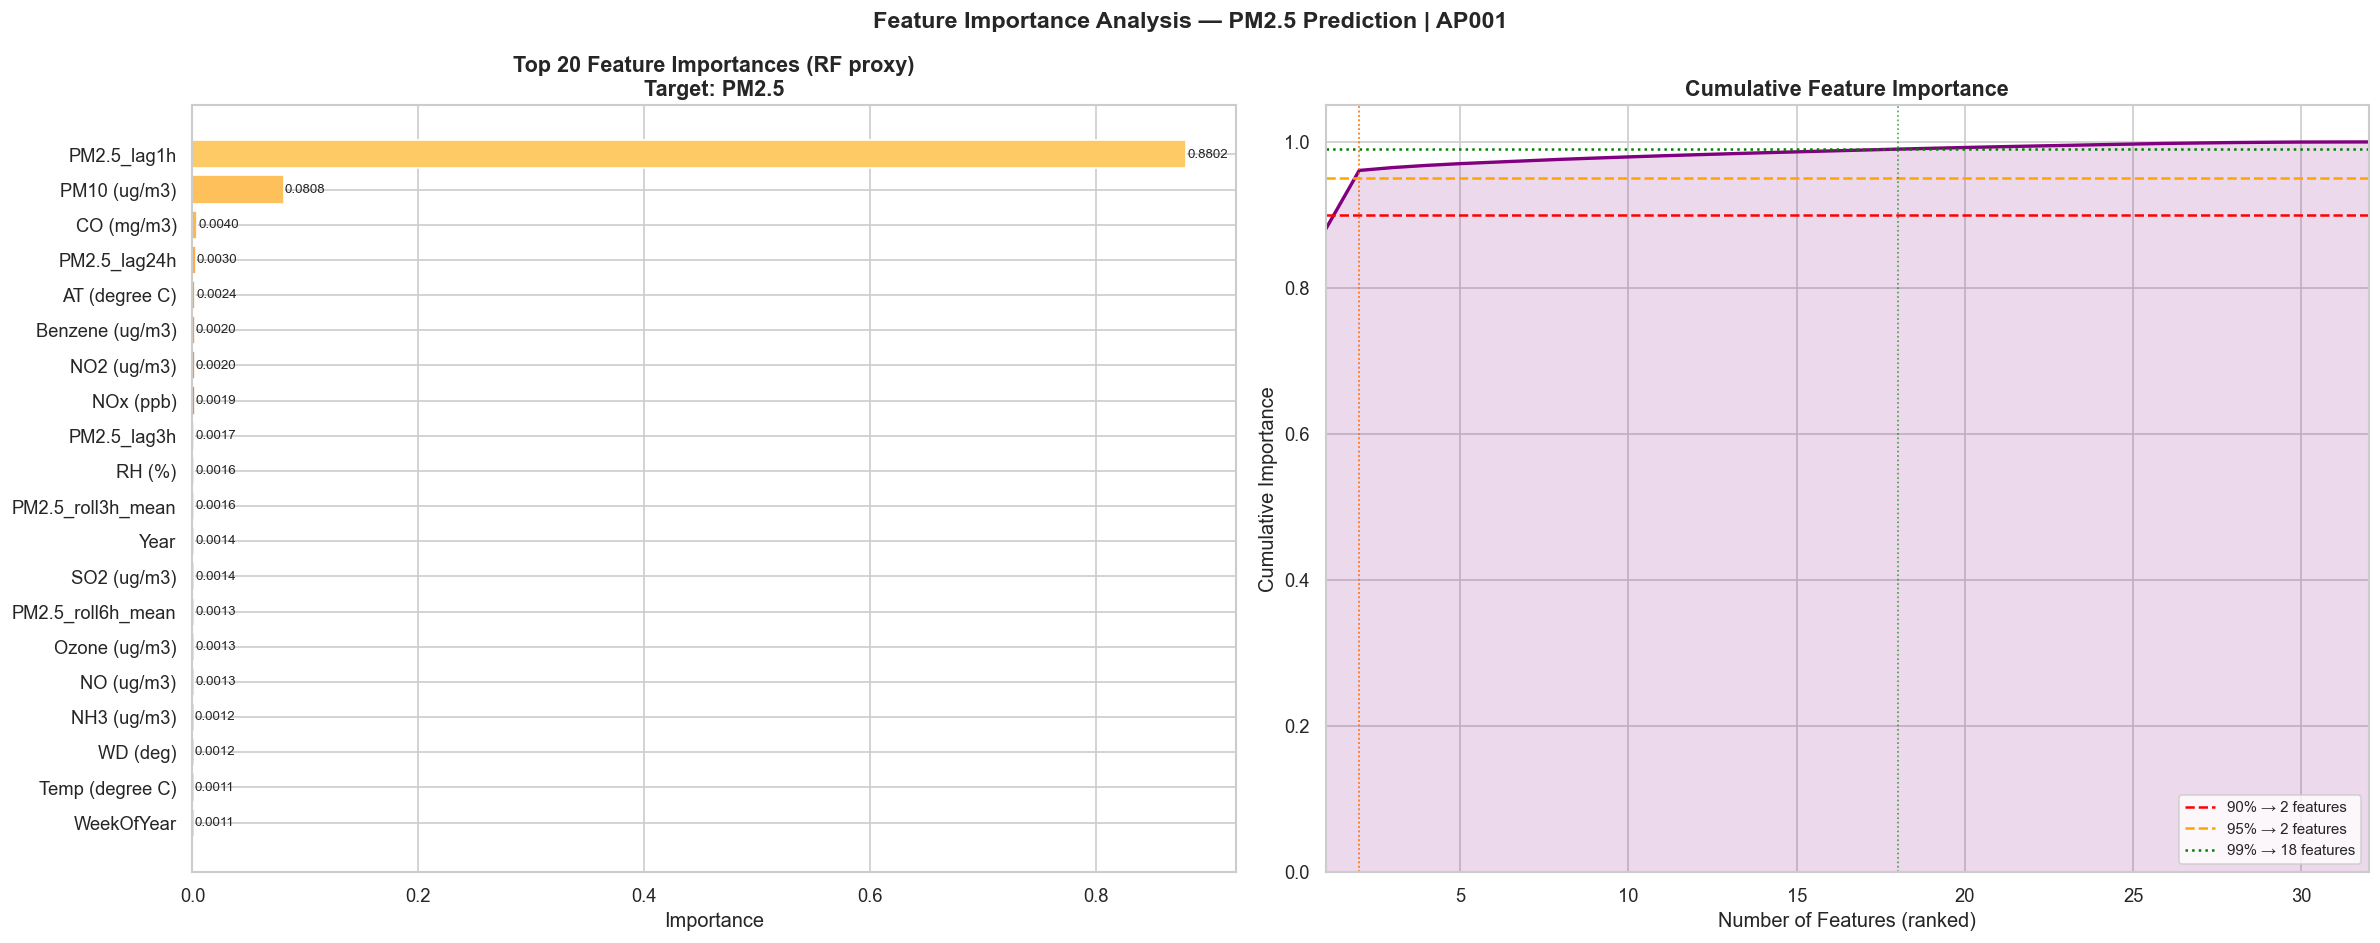


── Top 10 features by importance ──
   1. PM2.5_lag1h                         0.8802
   2. PM10 (ug/m3)                        0.0808
   3. CO (mg/m3)                          0.0040
   4. PM2.5_lag24h                        0.0030
   5. AT (degree C)                       0.0024
   6. Benzene (ug/m3)                     0.0020
   7. NO2 (ug/m3)                         0.0020
   8. NOx (ppb)                           0.0019
   9. PM2.5_lag3h                         0.0017
  10. RH (%)                              0.0016


In [22]:
print('Training RandomForest proxy for feature importance...')
rf_imp = RandomForestRegressor(n_estimators=100, random_state=SEED,
                                n_jobs=-1, max_depth=12)
rf_imp.fit(X_train, y_train)

importances = rf_imp.feature_importances_
feat_names  = np.array(FEATURE_COLS)
sorted_idx  = np.argsort(importances)[::-1]
top_n       = min(20, len(feat_names))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Top N feature bar chart ────────────────────────────────────────────────────
top_feats = feat_names[sorted_idx[:top_n]][::-1]
top_imps  = importances[sorted_idx[:top_n]][::-1]
colors_fi = plt.cm.YlOrRd(np.linspace(0.3, 0.9, top_n))
axes[0].barh(top_feats, top_imps, color=colors_fi[::-1], edgecolor='white')
for i, (feat, val) in enumerate(zip(top_feats, top_imps)):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
axes[0].set_title(f'Top {top_n} Feature Importances (RF proxy)\nTarget: PM2.5',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance')

# ── Cumulative importance ─────────────────────────────────────────────────────
cum_imp = np.cumsum(importances[sorted_idx])
axes[1].plot(range(1, len(cum_imp)+1), cum_imp, color='purple', lw=2)
axes[1].fill_between(range(1, len(cum_imp)+1), cum_imp, alpha=0.15, color='purple')
for thresh, col, ls in [(0.90, 'red', '--'), (0.95, 'orange', '--'), (0.99, 'green', ':')]:
    n_feat = np.searchsorted(cum_imp, thresh) + 1
    axes[1].axhline(thresh, color=col, ls=ls, lw=1.5,
                    label=f'{int(thresh*100)}% → {n_feat} features')
    axes[1].axvline(n_feat, color=col, ls=':', lw=1, alpha=0.7)
axes[1].set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Features (ranked)')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend(fontsize=9)
axes[1].set_xlim(1, len(feat_names))
axes[1].set_ylim(0, 1.05)

plt.suptitle('Feature Importance Analysis — PM2.5 Prediction | AP001',
             fontsize=14, fontweight='bold')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'AP001_feature_importance.png')
plt.savefig(p, bbox_inches='tight'); print(f'Saved: {p}')
plt.show()

print('\n── Top 10 features by importance ──')
for i, idx in enumerate(sorted_idx[:10], 1):
    print(f'  {i:2d}. {feat_names[idx]:<35} {importances[idx]:.4f}')

## Step 17: Final Folder Summary

In [23]:
print('\n' + '='*70)
print('              ALL FILES SAVED — FOLDER SUMMARY')
print('='*70)

folder_labels = [
    (DATA_RAW,       'data/raw/          — original AP001.csv'),
    (DATA_PROCESSED, 'data/processed/    — cleaned & imputed datasets'),
    (MODELS_DIR,     'models/            — trained TabM .pt weights'),
    (RESULTS_DIR,    'results/           — all plots + comparison CSV'),
    (LOGS_DIR,       'logs/              — training log .txt files'),
]

for folder, label in folder_labels:
    files = os.listdir(folder)
    print(f'\n📁 {label}')
    if files:
        for f in sorted(files):
            size = os.path.getsize(os.path.join(folder, f))
            unit = 'KB' if size < 1_000_000 else 'MB'
            sz   = size / 1024 if size < 1_000_000 else size / 1_048_576
            print(f'   ✅  {f:<60} ({sz:.1f} {unit})')
    else:
        print('   (empty — run all cells above first)')

print('\n' + '='*70)
print('  ✅  Run complete! All outputs saved to their respective folders.')
print('='*70)


              ALL FILES SAVED — FOLDER SUMMARY

📁 data/raw/          — original AP001.csv
   ✅  AP001.csv                                                    (7.8 MB)
   ✅  README.md                                                    (0.6 KB)
   ✅  city_day.csv                                                 (2.5 MB)

📁 data/processed/    — cleaned & imputed datasets
   ✅  AP001_cleaned.csv                                            (9.4 MB)
   ✅  AP001_median_imputed.csv                                     (10.4 MB)
   ✅  AP001_slm_imputed.csv                                        (11.3 MB)
   ✅  README.md                                                    (0.4 KB)
   ✅  cityday_cleaned.csv                                          (5.4 MB)
   ✅  cityday_median_imputed.csv                                   (4.7 MB)
   ✅  cityday_slm_imputed.csv                                      (7.4 MB)

📁 models/            — trained TabM .pt weights
   ✅  AP001_ft_transformer_median.pt           